### Applying K Means Clusteting algorithm to cluster satellites into 'shells'
- Since our dataset is completely ready for ML models, we will now group similar satellites together
using k means clustering unsupervised model

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Important thorughout this project
%matplotlib inline


In [102]:
df = pd.read_csv('../data/04_scaled/satellites_scaled.csv')

In [103]:
df.head()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,...,SAT_TYPE_Q,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z
0,-2.022090,0.714789,1.355178,-0.942297,0.320206,0.359963,-0.689055,0.173321,-0.015310,-0.045187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-2.401002,0.519315,1.355893,-0.905716,-0.624997,-1.974070,5.214405,-0.003116,-0.018490,-0.045187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-2.712870,2.246696,1.343978,0.414903,-0.598654,1.196229,5.997508,0.009780,-0.018422,-0.045187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-2.669983,2.153429,1.340065,-0.407631,1.779286,-0.409479,6.017279,0.028440,-0.018241,-0.045187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.447857,-0.017889,0.374159,0.109260,1.453082,-1.440140,-0.743557,0.274271,0.015453,-0.045187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Import necessary libraries

In [104]:
from sklearn.cluster import KMeans

In [105]:
# Create a model (we will use a random value for K), with a random state as 101
model = KMeans(n_clusters=5, random_state=101)

In [106]:
# Train and test the model
cluster_labels = model.fit_predict(df)

In [107]:
# predicted cluster label for each satellite
cluster_labels

array([3, 3, 3, ..., 0, 0, 0], shape=(12603,), dtype=int32)

In [108]:
# Make a seperate column
df['CLUSTER'] = cluster_labels

In [109]:
# Let's find the occurence of each cluster
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3    1126
4    1964
1    2273
0    2398
2    4842
Name: count, dtype: int64

---
#### The question is, how do we even interprete this, as we dont even know what that 0, 1 or any other cluster actually is..

In [110]:
df.corr(numeric_only=True)['CLUSTER'].sort_values()

ARG_OF_PERICENTER   -0.655104
MEAN_MOTION         -0.360907
ORBITAL_SPEED       -0.358899
MEAN_MOTION_DDOT    -0.059628
SAT_TYPE_X          -0.036046
SAT_TYPE_W          -0.034127
SAT_TYPE_U          -0.033452
SAT_TYPE_S          -0.030613
SAT_TYPE_V          -0.030583
SAT_TYPE_Y          -0.028931
SAT_TYPE_L          -0.028020
SAT_TYPE_Q          -0.027402
SAT_TYPE_R          -0.026809
SAT_TYPE_P          -0.026636
SAT_TYPE_M          -0.024954
SAT_TYPE_N          -0.024240
SAT_TYPE_T          -0.023835
SAT_TYPE_K          -0.012123
SAT_TYPE_J          -0.011575
SAT_TYPE_Z          -0.003270
SAT_TYPE_H          -0.002559
SAT_TYPE_G          -0.001118
SAT_TYPE_F           0.003541
SAT_TYPE_E           0.014904
SAT_TYPE_D           0.023600
MEAN_MOTION_DOT      0.032678
SAT_TYPE_C           0.038338
RA_OF_ASC_NODE       0.044136
SAT_TYPE_B           0.052311
BSTAR                0.074399
ECCENTRICITY         0.112662
SAT_TYPE_A           0.139218
AGE_SINCE_LAUNCH     0.313725
REV_AT_EPO

- Let's plot the above thing

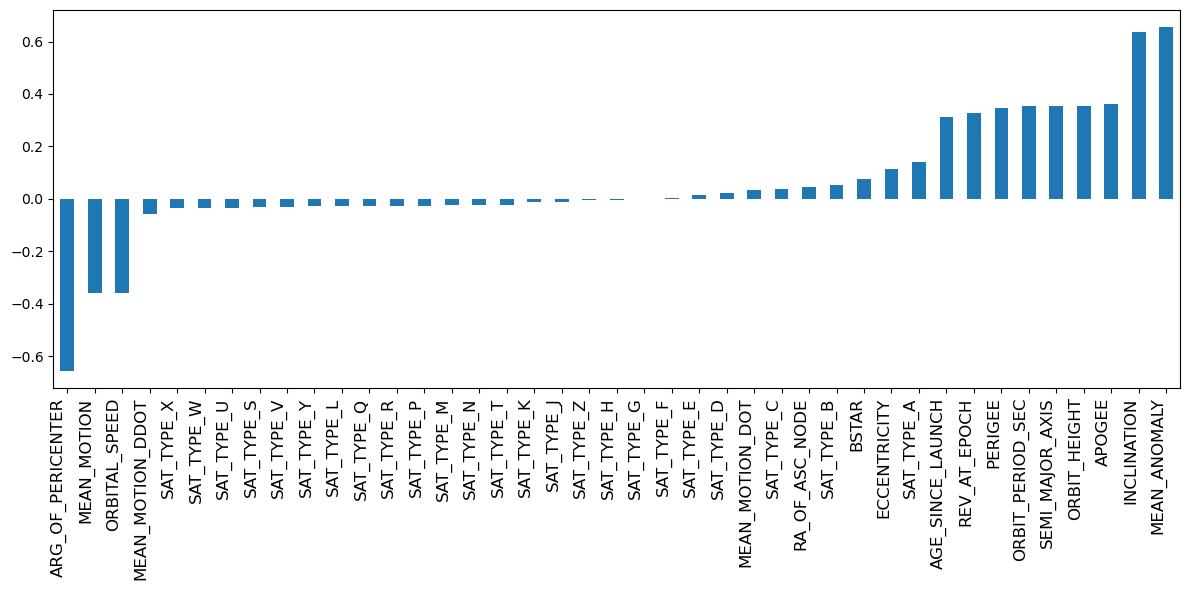

In [111]:
plt.figure(figsize=(12, 6))
df.corr(numeric_only=True)['CLUSTER'].sort_values()[:-1].plot(kind='bar')

plt.xticks(rotation=90, ha = 'right', fontsize = 12)
plt.tight_layout();

#### Interpreting the results for K = 5

- Let's consider the features having the most association with the cluster (both positive and negative)
- The featues most correlated are :
- ARG_OF_.., MEAN_MOTION_DOT, INCLINATION, AGE_SINCE_LAUNCH, REV_AT_EPOCH, MEAN_ANOMALY

In [112]:
most_corr_features = ['ARG_OF_PERICENTER', 'MEAN_MOTION_DOT', 'INCLINATION', 
                     'AGE_SINCE_LAUNCH', 'REV_AT_EPOCH', 'MEAN_ANOMALY'] 

In [113]:
grouped = df.groupby('CLUSTER')[most_corr_features].agg(['mean'])
grouped

,ARG_OF_PERICENTER,MEAN_MOTION_DOT,INCLINATION,AGE_SINCE_LAUNCH,REV_AT_EPOCH,MEAN_ANOMALY
,mean,mean,mean,mean,mean,mean
CLUSTER,,,,,,
0,1.114847,-0.147114,-0.258630,-0.348503,-0.419596,-1.120225
1,1.128544,0.118213,-0.646604,-0.216385,-0.192112,-1.132302
2,-0.755312,0.010344,-0.457537,-0.086930,-0.050597,0.765427
3,-0.478180,-0.018401,0.972457,0.545692,0.469409,0.463840
4,-0.531024,0.027858,1.634590,0.577402,0.590272,0.525223


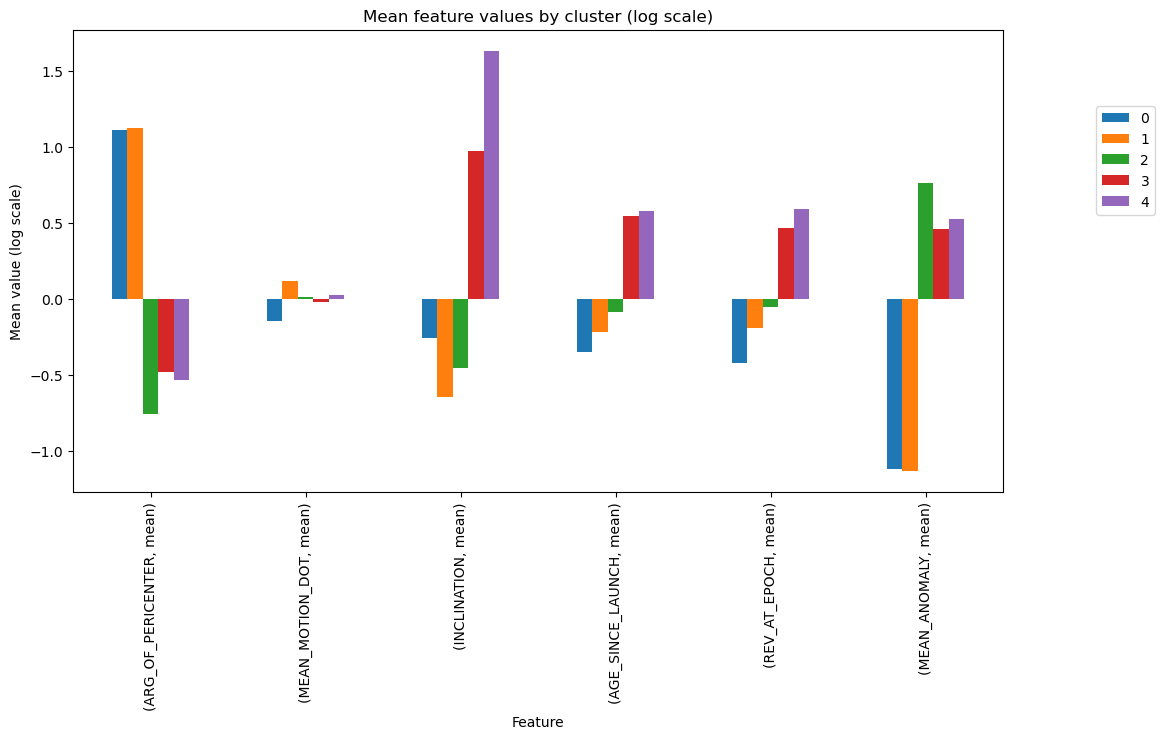

In [114]:
grouped.T.plot(kind='bar', figsize=(12,6)) 
plt.title("Mean feature values by cluster (log scale)")
plt.ylabel("Mean value (log scale)")
plt.xlabel("Feature")
plt.legend(loc=[1.1, 0.6])
plt.show()


- Physical meaning: 

| Cluster | Main Characteristic                             | Possible Satellite Type                     |
| ------- | ----------------------------------------------- | ------------------------------------------- |
| 0       | Newer, low-inclination, similar orientation     | Recently launched LEO constellations        |
| 1       | Mid-age, polar inclination                      | Earth-observation / reconnaissance          |
| 2       | Average across features                         | Transitional group                          |
| 3       | Old, low-moderate inclination, many revolutions | Aging operational satellites                |
| 4       | Very old, high-inclination                      | Polar / scientific or navigation satellites |


---
### Choosing optimal K value for clustering

In [115]:
ssd = []

# loop through k = 2 to 10 (basic estimation)
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=101)

    model.fit_predict(df) # Train the model
    ssd.append(model.inertia_) # append the SSD / inertia to the list

In [116]:
ssd # summed up ssd for each k value

[169000.70389853395,
 137658.54652284892,
 133728.89622579387,
 119333.74877328271,
 115961.50990477635,
 106922.21818165426,
 84541.27996594632,
 76244.12057557792,
 72084.07088618526]

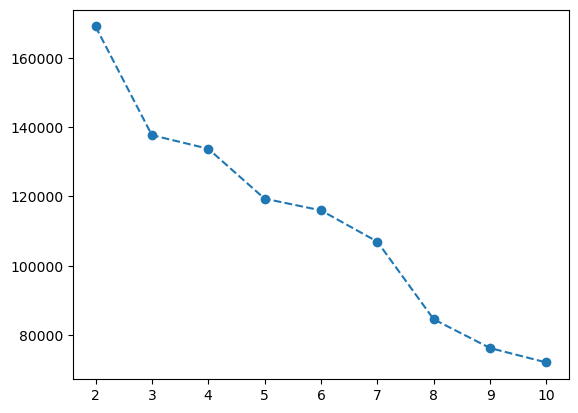

In [117]:
# Let's plot this
plt.plot(range(2, 11), ssd, 'o--')

- Let's find the difference between the SSDs

In [118]:
pd.Series(ssd).diff()

0             NaN
1   -31342.157376
2    -3929.650297
3   -14395.147453
4    -3372.238869
5    -9039.291723
6   -22380.938216
7    -8297.159390
8    -4160.049689
dtype: float64

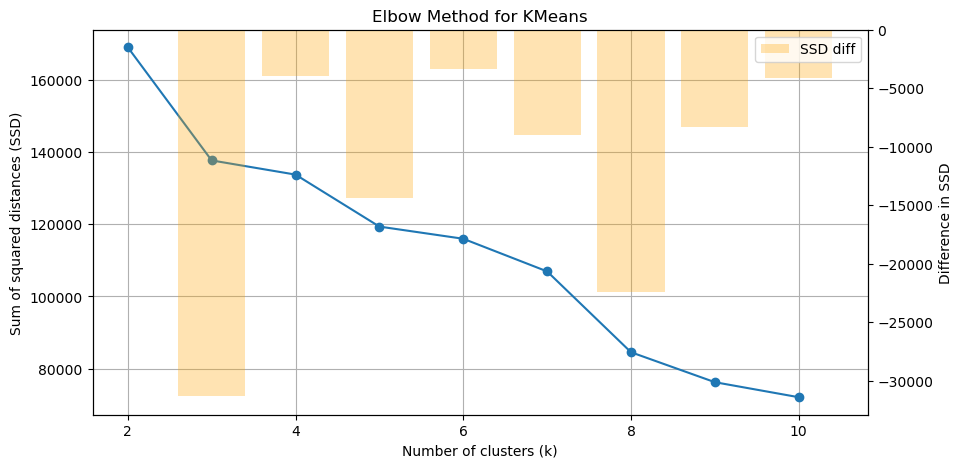

In [119]:
import matplotlib.pyplot as plt
import pandas as pd

# Your SSD values for k=2 to 10
K_range = range(2, 11)
# replace with your real SSD values

# Convert to Series for diff calculation
ssd_series = pd.Series(ssd, index=K_range)
ssd_diff = ssd_series.diff()

# Plot SSD vs K
plt.figure(figsize=(10,5))
plt.plot(K_range, ssd, 'o-', label='SSD (Inertia)')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of squared distances (SSD)')
plt.grid(True)

# Optional: show the difference as a bar
plt.twinx()
plt.bar(K_range, ssd_diff, alpha=0.3, color='orange', label='SSD diff')
plt.ylabel('Difference in SSD')
plt.legend(loc='upper right')

plt.show()


---
### KMeans Clustering Interpretation

We applied KMeans clustering to our scaled satellite dataset and used the **Elbow Method** to determine the optimal number of clusters.  

**Elbow Analysis:**  
- The plot of **Sum of Squared Distances (SSD) vs. number of clusters (k)** shows that SSD decreases sharply at first, then the rate of decrease slows down.  
- The **difference in SSD** (`.diff()`) highlights how much each additional cluster improves clustering.  
- Observing the plot, the “elbow” appears around **k = 5**, where adding more clusters provides diminishing returns.  

**Cluster Summary (k = 5):**  
1. **Cluster 0:**  
   - Low inclination (orbits close to equator)  
   - ARG_OF_PERICENTER above average → closest approach happens later along orbit  
   - Relatively new satellites  

2. **Cluster 1:**  
   - Moderate-to-high inclination → satellites tilted more from equator  
   - Average orbital orientation and age  

3. **Cluster 2:**  
   - Features close to dataset average → “typical” satellites  
   - No extreme orbital characteristics  

4. **Cluster 3:**  
   - High age and number of revolutions → older satellites  
   - Moderate inclination and ARG_OF_PERICENTER  

5. **Cluster 4:**  
   - Oldest satellites with many revolutions  
   - High inclination → likely polar or near-polar orbits  
   - Moderate ARG_OF_PERICENTER  




-----
#### Validating more for optimal K value
- We will use n_init=50 and also validate using the  Silhouette Score

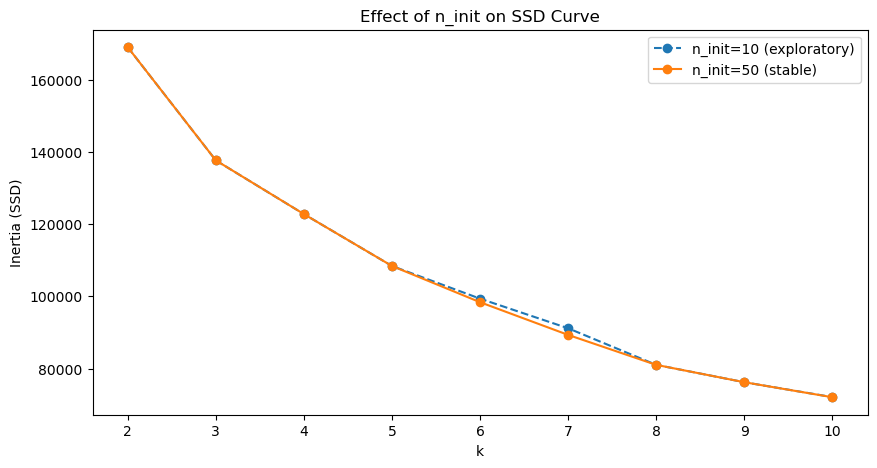

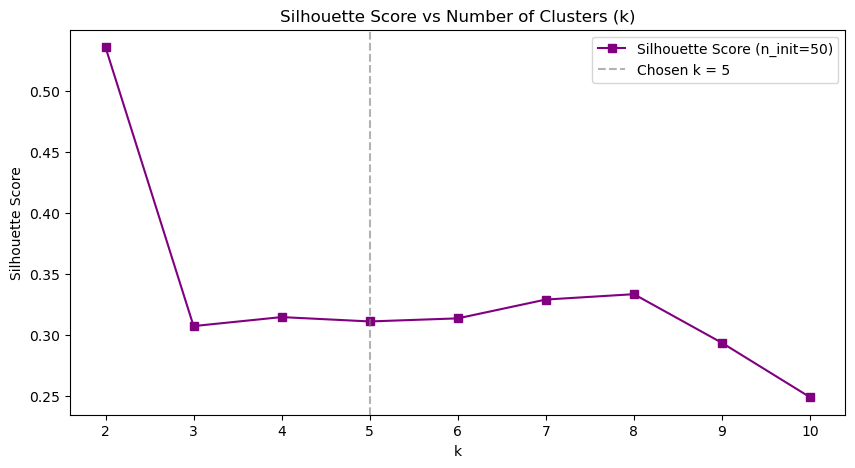

,k,SSD (n_init=50),Silhouette Score
0,2,169000.703899,0.535650
1,3,137657.292688,0.307458
2,4,122774.698987,0.314815
3,5,108402.327334,0.311248
4,6,98367.094151,0.313771
5,7,89315.600812,0.329174
6,8,81012.981745,0.333564
7,9,76206.907834,0.293715
8,10,72047.740980,0.249244


In [120]:
#!-------------- NOTE:  This code takes ages to run !! ------------------
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

ssd_10, ssd_50, sil_scores = [], [], []

for k in range(2, 11):
    km10 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(df)
    km50 = KMeans(n_clusters=k, n_init=50, random_state=42).fit(df)
    
    ssd_10.append(km10.inertia_)
    ssd_50.append(km50.inertia_)
    
    # silhouette score (using the more stable fit)
    labels = km50.labels_
    sil = silhouette_score(df, labels)
    sil_scores.append(sil)

# --- Plot 1: SSD (Inertia) ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), ssd_10, 'o--', label='n_init=10 (exploratory)')
plt.plot(range(2, 11), ssd_50, 'o-', label='n_init=50 (stable)')
plt.legend()
plt.title("Effect of n_init on SSD Curve")
plt.xlabel("k")
plt.ylabel("Inertia (SSD)")
plt.show()

# --- Plot 2: Silhouette Scores ---
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='purple', label='Silhouette Score (n_init=50)')
plt.axvline(5, color='gray', linestyle='--', alpha=0.6, label='Chosen k = 5')
plt.legend()
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

# --- Optional: print table ---
pd.DataFrame({
    'k': range(2, 11),
    'SSD (n_init=50)': ssd_50,
    'Silhouette Score': sil_scores
})


--- 
### 🛰️ Cluster Selection Analysis (KMeans)

We used two standard methods to determine the optimal number of clusters for our satellite dataset — the **Elbow Method** and the **Silhouette Score**.

#### 1. Elbow Method
The Elbow Method evaluates how the total **within-cluster variance (SSD)** decreases as the number of clusters (K) increases.  
In our case, the curve showed a clear “bend” or **elbow around K = 5**, indicating that after 5 clusters, the improvement in compactness slows down.  
This suggests that **five clusters offer a balanced tradeoff** between capturing meaningful structure and avoiding overfitting.

#### 2. Silhouette Score
The Silhouette Score measures **how well each data point fits within its cluster compared to others**, ranging from -1 to +1.  
A higher score means better separation between clusters.  
Our scores peaked at **K = 2 (≈0.55)**, suggesting that the dataset could be broadly separated into two main groups.  
However, since our dataset includes **only LEO-type satellites (no GEO or MEO)**, this “two-cluster” pattern likely reflects very broad distinctions (e.g., stable vs. decaying orbits), rather than detailed substructures.

#### 3. Why They Differ
- **Elbow** focuses on minimizing internal variance (compactness).
- **Silhouette** focuses on maximizing separation (distinctness).
- When both methods disagree, it usually means the data has **one dominant split** but also **smaller, meaningful variations** within that main structure.

#### 4. Final Choice — K = 5
We selected **K = 5** because:
- It aligns with the elbow point, balancing compactness and complexity.  
- It allows for finer segmentation of orbital behavior — capturing subtle subgroups such as:
  - satellites with stable vs. decaying orbits,  
  - newer vs. older launches,  
  - variations in inclination or mean motion behavior.  

Thus, **K = 5** provides a richer, more interpretable analysis of LEO satellite dynamics without oversimplifying the orbital diversity present in the dataset.


---
### Save the model output as CSV file
- Save both (scaled+label -> for future Regression model) and (unscaled+label -> for Isolation forest model)

In [121]:
# Save scaled version (for regression)
df.to_csv('../data/05_labeled/satellites_scaled_labeled.csv', index=False)

In [122]:
# Save the unscaled version (for anomaly detection)
import joblib

# Import the featured engineered dataset (containing unscaled data values)
unscaled = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

# Get the encoder which we used to encode the engineered dataset
encoder = joblib.load('../data/04_scaled/encoder_sat_type.joblib')

# Apply the same encoding
encoded = encoder.transform(unscaled[['SAT_TYPE']])

df_encoded = pd.concat([unscaled.drop('SAT_TYPE', axis=1), pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['SAT_TYPE']))], axis=1)

# Merge the corresponding cluster label
df_encoded['CLUSTER'] = df['CLUSTER']

# Save the CSV
df_encoded.to_csv('../data/05_labeled/satellites_unscaled_labeled.csv', index=False)

In [123]:
df_encoded

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,900,4320,0.000861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,902,82849,0.000074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,1512,93266,0.000132,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,1520,93529,0.000215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,2826,3595,0.001312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12598,2025-11-23 02:27:52.005600,12.858778,0.001154,66.0400,203.5092,270.5110,89.4586,66514,76,0.003963,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
12599,2025-11-23 21:30:25.224192,15.156665,0.001287,51.7997,61.1203,289.3668,70.5918,66545,72,0.000601,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
12600,2025-11-23 18:21:35.472096,15.154265,0.001053,51.7979,61.7429,288.2508,71.7322,66546,70,0.000597,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
12601,2025-11-23 18:22:38.587296,15.151745,0.001130,51.7989,61.7477,281.2558,78.7148,66547,70,0.000491,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


- Quick sanity check, wether or not the labels are correct or not

In [124]:
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3    1126
4    1964
1    2273
0    2398
2    4842
Name: count, dtype: int64

In [125]:
df_encoded['CLUSTER'].value_counts().sort_values()

CLUSTER
3    1126
4    1964
1    2273
0    2398
2    4842
Name: count, dtype: int64

In [126]:
df_encoded.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,2025-11-24 00:38:47.626368,13.763307,0.002630,90.2213,67.0218,189.7579,232.6051,900,4320,0.000861,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
1,2025-11-23 19:18:27.313056,13.528807,0.002055,90.2361,70.9479,102.8184,16.7196,902,82849,0.000074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2,2025-11-23 16:55:04.202400,13.335800,0.007137,89.9895,212.6858,105.2414,309.9552,1512,93266,0.000132,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,2025-11-23 22:01:14.414880,13.362341,0.006863,89.9085,124.4058,323.9637,161.4359,1520,93529,0.000215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,2025-11-23 23:24:19.305216,14.737562,0.000474,69.9169,179.8821,293.9595,66.1053,2826,3595,0.001312,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


In [130]:
len(df_encoded)

12603